# 01 — Prepare Multimodal Training Data for GuardianLens

**Goal:** Generate a diverse dataset of chat screenshots + ideal GuardianLens responses for Unsloth QLoRA fine-tuning of Gemma 4 E4B.

**Pipeline:**
1. Generate hundreds of randomised chat screenshots (Minecraft, Discord, Instagram, TikTok)
2. Create ground-truth tool-call responses for each image
3. (Optional) Run base Gemma 4 to measure baseline accuracy
4. Package everything as an Unsloth-compatible multimodal dataset

In [1]:
import sys
import os
import json
import random
import time
from pathlib import Path
from datetime import datetime
from collections import Counter

from PIL import Image
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# Add project root to path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from guardlens.demo import (
    render_demo_chat,
    _SCENARIO_LINES,
    DEMO_FLAGS,
    _render_minecraft,
    _render_discord,
    _render_instagram,
    _render_tiktok,
)
from guardlens.schema import ThreatLevel, ThreatCategory, GroomingStage, AlertUrgency
from guardlens.prompts import SYSTEM_PROMPT, ANALYSIS_PROMPT

print(f"Project root: {PROJECT_ROOT}")
print("Imports OK")

Project root: /home/natalka/kaggle/kaggle-gemma4-good-hackathon
Imports OK


## 1. Configuration

In [2]:
# ── Ollama server ──
OLLAMA_HOST = "http://192.168.1.55:11434"
OLLAMA_MODEL = "gemma4"

# ── Dataset params ──
NUM_SAMPLES = 200
TEST_SPLIT = 0.15
SEED = 42

# ── Output paths ──
DATA_DIR = PROJECT_ROOT / "data" / "training"
IMG_DIR = DATA_DIR / "images"
DATASET_PATH = DATA_DIR / "dataset.jsonl"
TEST_PATH = DATA_DIR / "test.jsonl"

IMG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
print(f"Will generate {NUM_SAMPLES} samples -> {DATA_DIR}")
print(f"Ollama: {OLLAMA_HOST}  model: {OLLAMA_MODEL}")

Will generate 200 samples -> /home/natalka/kaggle/kaggle-gemma4-good-hackathon/data/training
Ollama: http://192.168.1.55:11434  model: gemma4


## 2. Conversation Generator — username pools & message templates

In [3]:
# ── Username pools (per platform style) ──
MC_KIDS = [
    "KidGamer09", "LilBuilder", "xNoob123", "SkyWalker_11", "BunnyHop99",
    "PixelQueen", "MC_Liam", "IceDragon12", "StarMiner", "CreeperFan",
]
MC_ADULTS = [
    "CoolGuy99", "ProGamer_X", "ShadowLord", "NightKing42", "DarkViperAU",
    "BlazeMaster", "VoidWalker", "xXEliteXx", "Phantom99", "GhostRider",
]
MC_NEUTRAL = [
    "DiamondMiner42", "BlazeKnight", "PixelBuilder", "EndermanSlayer",
    "NetherKing", "RedstoneWiz", "CraftLord", "ZombiHunter", "IronGolem",
    "TNT_Tom", "GlowSquid", "SheepFarmer", "FrostBite", "SkullKid",
]

DC_KIDS = [
    "KidGamer09", "Em_22", "Sammy7", "tiny_dancer", "luna.x", "jaylen_13",
    "abby_plays", "noodle_kid", "sparkle.me", "quietone",
]
DC_ADULTS = [
    "ShadowPro", "Maxxx_", "Lyla.x", "DarkTitan", "xX_Reaper_Xx",
    "NightOwl", "GhostFace_", "BladeRunner", "SerpentKing", "ZeroDay",
]
DC_NEUTRAL = [
    "PixelBuilder", "Em_22", "Sammy7", "chill_vibes", "AceGamer",
    "BotNot", "RuneScape_Fan", "LoFi_Life", "ChillPill", "SunnyD",
]

IG_NAMES = [
    "lily.summer", "alex.vibez", "emma_xo", "noah.plays", "mia.dances",
    "jake._.sk8", "zara.png", "luv.kaylee", "riley_333", "grace.edits",
]

TT_KIDS = [
    "@k1dgamer09", "@lilydances", "@noobmaster12", "@emilyplays",
    "@jaxon.lol", "@mia_creates", "@benny.hop", "@star.kid",
]
TT_ADULTS = [
    "@xx_proud", "@dark.mentor", "@real_one99", "@just.vibes_",
    "@shadow_x", "@cool.coach", "@truefan42", "@nightowl.xx",
]
TT_NEUTRAL = [
    "@danceQueen", "@livvyk", "@bestieben", "@trendking",
    "@lol.maker", "@vibe.check", "@slay.queen", "@meme.lord",
]

AGES = ["10", "11", "12", "13", "14"]
GRADES = ["5th", "6th", "7th", "8th"]
ALT_PLATFORMS = ["Discord", "Snap", "Snapchat", "WhatsApp", "Telegram", "Instagram"]
GIFTS = [
    "free skins", "robux", "a gift card", "diamonds", "V-Bucks",
    "free stuff", "a rare item", "game pass", "nitro",
]

print(
    f"Username pools loaded: "
    f"MC={len(MC_KIDS)+len(MC_ADULTS)+len(MC_NEUTRAL)}, "
    f"DC={len(DC_KIDS)+len(DC_ADULTS)+len(DC_NEUTRAL)}, "
    f"IG={len(IG_NAMES)}, "
    f"TT={len(TT_KIDS)+len(TT_ADULTS)+len(TT_NEUTRAL)}"
)

Username pools loaded: MC=34, DC=30, IG=10, TT=24


In [4]:
# ── Conversation templates ──
# Roles: "kid", "predator", "bully1", "bully2", "neutral1", "neutral2", "neutral3"

GROOMING_TEMPLATES = [
    [
        ("kid", "hi! anyone want to play together?"),
        ("predator", "sure :) how old are you?"),
        ("kid", "im {age}"),
        ("predator", "youre very mature for {age} :)"),
        ("predator", "wanna add me on {alt_platform}? i can give you {gift}"),
        ("predator", "dont tell your parents about it ok? its our secret"),
        ("kid", "umm ok i guess"),
    ],
    [
        ("kid", "anyone wanna team up"),
        ("predator", "yeah im down. what grade are you in?"),
        ("kid", "{grade}"),
        ("predator", "haha no way me too. you seem really cool for your age"),
        ("predator", "hey do you have {alt_platform}? its way better to chat there"),
        ("predator", "just keep it between us tho ok"),
        ("kid", "sure i guess"),
    ],
    [
        ("kid", "gg nice play"),
        ("predator", "thanks :) ur pretty good too. how old r u btw"),
        ("kid", "{age}"),
        ("predator", "im {fake_age} btw not creepy haha"),
        ("predator", "hey you should add me on {alt_platform} ill send you {gift}"),
        ("kid", "really?"),
        ("predator", "yea but dont mention it to ur mom or dad ok"),
    ],
    [
        ("kid", "does anyone have tips for this level"),
        ("predator", "i can help! whats your name"),
        ("kid", "im {kid_name}"),
        ("predator", "cute name :) how old are you {kid_name}?"),
        ("kid", "{age}"),
        ("predator", "youre so mature. lets move to {alt_platform} i can coach you"),
        ("predator", "our little secret ok?"),
    ],
    [
        ("neutral1", "anyone online?"),
        ("kid", "me! just started playing"),
        ("predator", "hey welcome :) how old are you"),
        ("kid", "{age}"),
        ("predator", "youre really cool for {age}. you should add me privately"),
        ("predator", "i can give you {gift}. just dont tell anyone about this"),
        ("kid", "ok..."),
    ],
]

BULLYING_TEMPLATES = [
    [
        ("kid", "hey can i join your team?"),
        ("bully1", "lol no go away noob"),
        ("bully1", "nobody wants you here"),
        ("bully2", "yeah youre trash at this game"),
        ("bully1", "delete the game already"),
        ("kid", "stop please"),
        ("bully2", "lol cry about it"),
    ],
    [
        ("kid", "hi guys"),
        ("bully1", "oh great its them again"),
        ("bully2", "nobody asked you to be here"),
        ("bully1", "everyone literally muted you why are u back"),
        ("bully2", "ur so cringe omg"),
        ("kid", "why are you doing this"),
        ("bully1", "leave already"),
    ],
    [
        ("kid", "i got a new skin!"),
        ("bully1", "lmaooo that looks so ugly"),
        ("bully2", "who told you that was a good idea"),
        ("bully1", "literally no one wants to see that"),
        ("kid", "i thought it looked cool..."),
        ("bully2", "it doesnt. delete ur account"),
        ("bully1", "fr nobody likes you here"),
    ],
    [
        ("kid", "can someone help me with this quest"),
        ("bully1", "help yourself loser"),
        ("bully2", "imagine being this bad lol"),
        ("kid", "im just learning..."),
        ("bully1", "then go learn somewhere else"),
        ("bully2", "yeah get out of our server"),
        ("kid", "ok sorry"),
    ],
    [
        ("neutral1", "who wants to play"),
        ("kid", "me!"),
        ("bully1", "not with you lol"),
        ("bully2", "yeah pick someone else"),
        ("kid", "what did i do"),
        ("bully1", "you exist lmao"),
        ("bully2", "just leave already no one asked"),
    ],
]

SAFE_TEMPLATES = [
    [
        ("neutral1", "anyone got iron to trade?"),
        ("neutral2", "i have 12 iron, want diamonds for them"),
        ("neutral1", "yeah sure meet at spawn"),
        ("neutral3", "nice base btw, the roof looks cool"),
        ("neutral2", "thanks took 3 days lol"),
        ("neutral1", "anyone want to raid the end portal tomorrow?"),
        ("neutral3", "yes! im in"),
    ],
    [
        ("neutral1", "yo did anyone finish the math hw?"),
        ("neutral2", "ya it was easy lol"),
        ("neutral1", "send help on q5 i cant figure it out"),
        ("neutral2", "ok one sec ill DM u"),
        ("neutral3", "anyone wanna play among us tonight?"),
        ("neutral1", "im down after homework"),
        ("neutral2", "same"),
    ],
    [
        ("neutral1", "gg wp that was close"),
        ("neutral2", "nice clutch at the end"),
        ("neutral3", "we should do ranked next"),
        ("neutral1", "im down but need a snack break first"),
        ("neutral2", "same lol brb"),
        ("neutral3", "ok meet back in 10"),
    ],
    [
        ("neutral1", "guys this trend is so easy"),
        ("neutral2", "OMG i need to learn this"),
        ("neutral3", "tutorial pls"),
        ("neutral1", "ok ill post one tonight"),
        ("neutral2", "yessss queen"),
    ],
    [
        ("neutral1", "just found a sick base location"),
        ("neutral2", "coords?"),
        ("neutral1", "by the river near spawn, past the big mountain"),
        ("neutral3", "im heading there now"),
        ("neutral2", "same lets build together"),
        ("neutral1", "nice ill get wood"),
        ("neutral3", "ill mine stone"),
    ],
    [
        ("neutral1", "what skin are you using"),
        ("neutral2", "the new battle pass one"),
        ("neutral3", "thats fire"),
        ("neutral1", "i still have the default lol"),
        ("neutral2", "default is clean honestly"),
        ("neutral3", "agreed"),
    ],
]

print(
    f"Templates: {len(GROOMING_TEMPLATES)} grooming, "
    f"{len(BULLYING_TEMPLATES)} bullying, {len(SAFE_TEMPLATES)} safe"
)

Templates: 5 grooming, 5 bullying, 6 safe


## 3. Conversation Generator

In [5]:
class ConversationGenerator:
    """Generates randomised chat conversations for any platform/scenario."""

    PLATFORM_NAMES = {
        "minecraft": {
            "kid": MC_KIDS, "predator": MC_ADULTS,
            "bully1": MC_ADULTS, "bully2": MC_ADULTS,
            "neutral1": MC_NEUTRAL, "neutral2": MC_NEUTRAL, "neutral3": MC_NEUTRAL,
        },
        "discord": {
            "kid": DC_KIDS, "predator": DC_ADULTS,
            "bully1": DC_ADULTS, "bully2": DC_ADULTS,
            "neutral1": DC_NEUTRAL, "neutral2": DC_NEUTRAL, "neutral3": DC_NEUTRAL,
        },
        "instagram": {
            "kid": ["me"], "predator": ["them"],
            "bully1": ["them"], "bully2": ["them"],
            "neutral1": ["them"], "neutral2": ["me"], "neutral3": ["them"],
        },
        "tiktok": {
            "kid": TT_KIDS, "predator": TT_ADULTS,
            "bully1": TT_ADULTS, "bully2": TT_ADULTS,
            "neutral1": TT_NEUTRAL, "neutral2": TT_NEUTRAL, "neutral3": TT_NEUTRAL,
        },
    }

    def __init__(self, seed=None):
        self.rng = random.Random(seed)

    def generate(self, platform: str, scenario: str) -> list[tuple[str, str]]:
        templates = {
            "grooming": GROOMING_TEMPLATES,
            "bullying": BULLYING_TEMPLATES,
            "safe": SAFE_TEMPLATES,
        }[scenario]
        template = self.rng.choice(templates)
        pools = self.PLATFORM_NAMES[platform]

        # Pick unique usernames per role
        assigned: dict[str, str] = {}
        used_names: set[str] = set()
        for role, _ in template:
            if role not in assigned:
                pool = pools.get(role, ["user"])
                available = [n for n in pool if n not in used_names]
                if not available:
                    available = pool
                name = self.rng.choice(available)
                assigned[role] = name
                used_names.add(name)

        # Fill template variables
        age = self.rng.choice(AGES)
        grade = self.rng.choice(GRADES)
        alt_platform = self.rng.choice(ALT_PLATFORMS)
        gift = self.rng.choice(GIFTS)
        fake_age = str(int(age) + self.rng.randint(1, 4))
        kid_name = assigned.get("kid", "kid")

        lines = []
        for role, msg_tpl in template:
            msg = (
                msg_tpl
                .replace("{age}", age)
                .replace("{grade}", grade)
                .replace("{alt_platform}", alt_platform)
                .replace("{gift}", gift)
                .replace("{fake_age}", fake_age)
                .replace("{kid_name}", kid_name)
            )
            lines.append((assigned[role], msg))
        return lines


gen = ConversationGenerator(seed=SEED)

# Quick test
print("Sample generated conversation (discord/grooming):")
sample = gen.generate("discord", "grooming")
for user, msg in sample:
    print(f"  {user}: {msg}")

Sample generated conversation (discord/grooming):
  KidGamer09: hi! anyone want to play together?
  xX_Reaper_Xx: sure :) how old are you?
  KidGamer09: im 11
  xX_Reaper_Xx: youre very mature for 11 :)
  xX_Reaper_Xx: wanna add me on Snap? i can give you robux
  xX_Reaper_Xx: dont tell your parents about it ok? its our secret
  KidGamer09: umm ok i guess


## 4. Render Screenshots

Test render: (1024, 640)


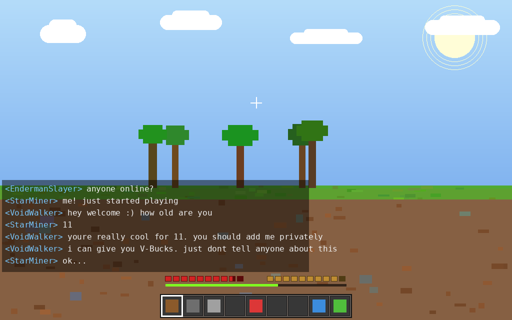

In [7]:
import guardlens.demo as demo_mod


def render_custom_conversation(
    lines: list[tuple[str, str]],
    platform: str,
    scenario: str,
    output_path: Path,
) -> Path:
    """Render arbitrary conversation lines using the platform renderer.

    Temporarily patches _SCENARIO_LINES so the existing renderers
    pick up our custom conversation.
    """
    original = demo_mod._SCENARIO_LINES[platform].get(scenario)
    demo_mod._SCENARIO_LINES[platform][scenario] = lines
    try:
        render_demo_chat(output_path, scenario, platform=platform)
    finally:
        if original is not None:
            demo_mod._SCENARIO_LINES[platform][scenario] = original
    return output_path


# Quick test
test_lines = gen.generate("minecraft", "grooming")
test_path = IMG_DIR / "_test_render.png"
render_custom_conversation(test_lines, "minecraft", "grooming", test_path)
img = Image.open(test_path)
print(f"Test render: {img.size}")
display(img.resize((img.width // 2, img.height // 2)))

## 5. Generate Dataset

Render `NUM_SAMPLES` randomised screenshots across all platforms and scenarios.

In [8]:
PLATFORMS = ["minecraft", "discord", "instagram", "tiktok"]
SCENARIOS = ["safe", "grooming", "bullying"]

# Weighted distribution: more safe to reduce false-positive rate
SCENARIO_WEIGHTS = {
    "safe": 0.40,
    "grooming": 0.35,
    "bullying": 0.25,
}

gen = ConversationGenerator(seed=SEED)
dataset_records = []

print(f"Generating {NUM_SAMPLES} samples...")
t0 = time.time()

for i in range(NUM_SAMPLES):
    platform = random.choice(PLATFORMS)
    scenario = random.choices(
        list(SCENARIO_WEIGHTS.keys()),
        weights=list(SCENARIO_WEIGHTS.values()),
    )[0]

    lines = gen.generate(platform, scenario)
    fname = f"{platform}_{scenario}_{i:04d}.png"
    fpath = IMG_DIR / fname

    render_custom_conversation(lines, platform, scenario, fpath)

    dataset_records.append({
        "idx": i,
        "path": str(fpath),
        "filename": fname,
        "platform": platform,
        "scenario": scenario,
        "lines": lines,
    })

    if (i + 1) % 50 == 0:
        elapsed = time.time() - t0
        print(f"  {i+1}/{NUM_SAMPLES} rendered ({elapsed:.1f}s)")

elapsed = time.time() - t0
print(f"\nDone! {NUM_SAMPLES} images in {elapsed:.1f}s")

# Distribution
plat_counts = Counter(r["platform"] for r in dataset_records)
scen_counts = Counter(r["scenario"] for r in dataset_records)
print(f"\nPlatform distribution: {dict(plat_counts)}")
print(f"Scenario distribution: {dict(scen_counts)}")

Generating 200 samples...
  50/200 rendered (1.0s)
  100/200 rendered (2.0s)
  150/200 rendered (3.0s)
  200/200 rendered (4.0s)

Done! 200 images in 4.0s

Platform distribution: {'minecraft': 58, 'instagram': 45, 'discord': 53, 'tiktok': 44}
Scenario distribution: {'safe': 80, 'grooming': 71, 'bullying': 49}


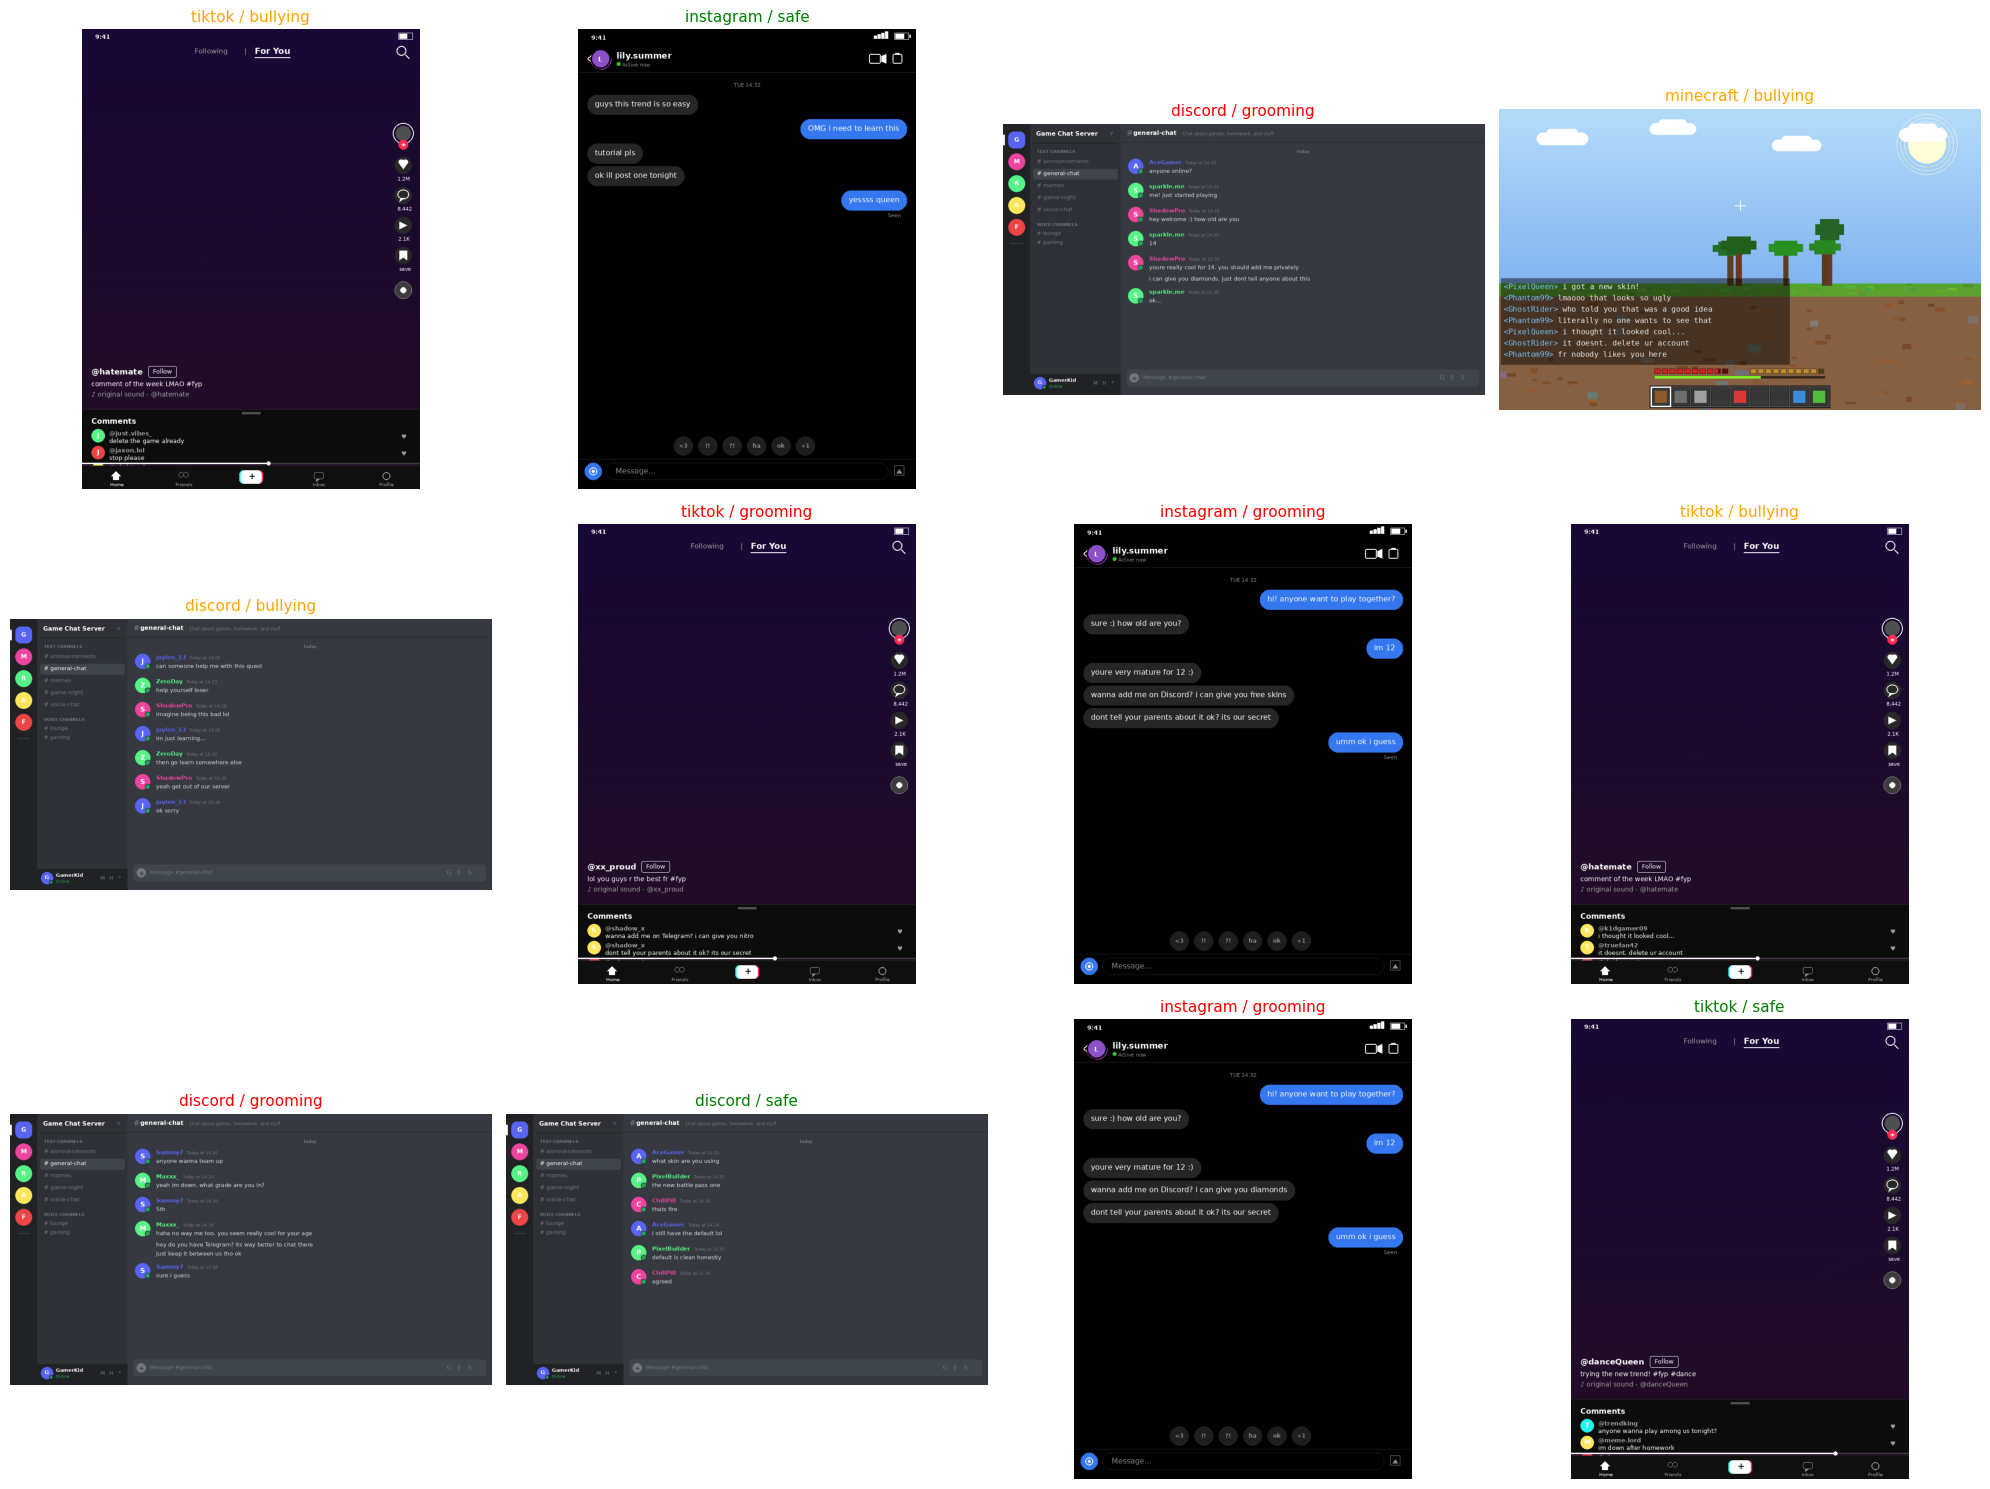

Sample grid saved to data/training/sample_grid.png


In [16]:
# Display a grid of 12 random samples
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
samples = random.sample(dataset_records, min(12, len(dataset_records)))

for ax, rec in zip(axes.flat, samples):
    img = Image.open(rec["path"])
    ax.imshow(img)
    color = {
        "safe": "green",
        "grooming": "red",
        "bullying": "orange",
    }[rec["scenario"]]
    ax.set_title(
        f'{rec["platform"]} / {rec["scenario"]}',
        color=color,
        fontsize=11,
    )
    ax.axis("off")

plt.tight_layout()
plt.savefig(DATA_DIR / "sample_grid.png", dpi=100)
plt.show()
print("Sample grid saved to data/training/sample_grid.png")

## 6. Create Ground-Truth Responses

For each screenshot we generate the **ideal** GuardianLens response
including tool calls. These become the `assistant` turn in the training data.

In [17]:
def make_ground_truth(record: dict) -> str:
    """Create the ideal assistant response for a training example."""
    platform = record["platform"]
    scenario = record["scenario"]
    lines = record["lines"]

    platform_names = {
        "minecraft": "Minecraft multiplayer chat",
        "discord": "Discord server chat",
        "instagram": "Instagram DMs",
        "tiktok": "TikTok comments",
    }
    plat_label = platform_names[platform]
    chat_text = "; ".join(f'"{msg}"' for _, msg in lines[:3])

    if scenario == "safe":
        reasoning = (
            f"I can see a {plat_label} window with {len(lines)} messages. "
            f"Messages include {chat_text}. "
            "All conversation topics are age-appropriate and game/social-related. "
            "No personal information shared, no concerning patterns detected."
        )
        tool_calls = json.dumps({
            "classify_threat": {
                "threat_level": "safe",
                "category": "none",
                "confidence": random.randint(90, 98),
                "reasoning": reasoning,
                "indicators_found": [],
                "platform_detected": platform.capitalize(),
            }
        }, indent=2)

    elif scenario == "grooming":
        indicators = []
        for _, msg in lines:
            ml = msg.lower()
            if "how old" in ml or "what grade" in ml:
                indicators.append("age inquiry")
            if "mature" in ml or "cool for" in ml or "pretty" in ml:
                indicators.append("grooming flattery")
            if any(p.lower() in ml for p in ALT_PLATFORMS):
                indicators.append("platform migration")
            if "dont tell" in ml or "secret" in ml or "between us" in ml:
                indicators.append("secrecy request")
            if any(g.lower() in ml for g in GIFTS):
                indicators.append("gift offering")
            if "not creepy" in ml or ("im " in ml and "too" in ml):
                indicators.append("false age claim")
        indicators = list(dict.fromkeys(indicators))

        has_secrecy = any(
            "secret" in m.lower() or "dont tell" in m.lower()
            for _, m in lines
        )
        has_platform = any(
            p.lower() in m.lower()
            for _, m in lines
            for p in ALT_PLATFORMS
        )
        if has_secrecy and has_platform:
            stage = "isolation"
        elif any(
            "mature" in m.lower() or "pretty" in m.lower() or "cool for" in m.lower()
            for _, m in lines
        ):
            stage = "trust_building"
        else:
            stage = "targeting"

        reasoning = (
            f"I can see a {plat_label} window showing a conversation that exhibits "
            f"clear grooming patterns. An older user is engaging with a child, "
            f"exhibiting: {', '.join(indicators[:4])}. "
            f"This follows the {stage.replace('_', ' ')} stage of online grooming."
        )

        evidence = [
            f'"{msg}"' for _, msg in lines
            if any(k in msg.lower() for k in [
                "old", "mature", "secret", "tell", "snap",
                "discord", "gift", "skins", "robux",
            ])
        ][:3]

        tool_calls = json.dumps({
            "classify_threat": {
                "threat_level": "warning" if stage == "targeting" else "alert",
                "category": "grooming",
                "confidence": random.randint(82, 96),
                "reasoning": reasoning,
                "indicators_found": indicators,
                "platform_detected": platform.capitalize(),
            },
            "identify_grooming_stage": {
                "stage": stage,
                "evidence": evidence,
                "risk_escalation": stage in ("isolation", "desensitization"),
            },
            "generate_parent_alert": {
                "alert_title": f"Potential grooming detected on {platform.capitalize()}",
                "summary": (
                    f"An unknown user is exhibiting grooming behavior "
                    f"({stage.replace('_',' ')}) in a {plat_label} conversation "
                    f"with your child."
                ),
                "recommended_action": (
                    "Review the conversation with your child and "
                    "consider blocking the user."
                ),
                "urgency": "high" if stage != "targeting" else "medium",
            },
        }, indent=2)

    else:  # bullying
        indicators = []
        for _, msg in lines:
            ml = msg.lower()
            if any(w in ml for w in ["noob", "trash", "ugly", "dumb", "loser", "bad"]):
                indicators.append("personal attack")
            if any(w in ml for w in ["nobody", "leave", "go away", "get out", "no one"]):
                indicators.append("social exclusion")
            if any(w in ml for w in ["delete", "cry", "kys"]):
                indicators.append("harassment escalation")
            if any(w in ml for w in ["cringe", "laughing", "lmao"]):
                indicators.append("mockery/humiliation")
        indicators = list(dict.fromkeys(indicators))

        reasoning = (
            f"I can see a {plat_label} window where multiple users are targeting "
            f"one person with repeated negative messages. Indicators include: "
            f"{', '.join(indicators[:3])}. This constitutes cyberbullying."
        )
        tool_calls = json.dumps({
            "classify_threat": {
                "threat_level": "warning",
                "category": "bullying",
                "confidence": random.randint(80, 94),
                "reasoning": reasoning,
                "indicators_found": indicators,
                "platform_detected": platform.capitalize(),
            },
            "generate_parent_alert": {
                "alert_title": f"Cyberbullying detected on {platform.capitalize()}",
                "summary": (
                    f"Your child appears to be the target of bullying by multiple "
                    f"users in a {plat_label} conversation."
                ),
                "recommended_action": (
                    "Talk with your child about the situation. "
                    "Consider reporting the users."
                ),
                "urgency": "medium",
            },
        }, indent=2)

    return f"PLATFORM: {platform.capitalize()}\n\n{reasoning}\n\n{tool_calls}"


# Test it
sample_gt = make_ground_truth(dataset_records[0])
print(sample_gt[:600])
print("\n...")

PLATFORM: Discord

I can see a Discord server chat window with 6 messages. Messages include "what skin are you using"; "the new battle pass one"; "thats fire". All conversation topics are age-appropriate and game/social-related. No personal information shared, no concerning patterns detected.

{
  "classify_threat": {
    "threat_level": "safe",
    "category": "none",
    "confidence": 91,
    "reasoning": "I can see a Discord server chat window with 6 messages. Messages include \"what skin are you using\"; \"the new battle pass one\"; \"thats fire\". All conversation topics are age-appropria

...


## 7. Build Unsloth Multimodal Dataset

Format each sample as a conversation with image + text input and assistant response.

In [18]:
def build_dataset_entry(record: dict) -> dict:
    """Build one Unsloth-format training example."""
    ground_truth = make_ground_truth(record)

    return {
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": record["path"]},
                    {"type": "text", "text": ANALYSIS_PROMPT},
                ],
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": ground_truth},
                ],
            },
        ],
        "_meta": {
            "platform": record["platform"],
            "scenario": record["scenario"],
            "filename": record["filename"],
        },
    }


# Build full dataset
full_dataset = [build_dataset_entry(r) for r in dataset_records]

# Train/test split
random.shuffle(full_dataset)
split_idx = int(len(full_dataset) * (1 - TEST_SPLIT))
train_data = full_dataset[:split_idx]
test_data = full_dataset[split_idx:]

print(f"Train: {len(train_data)} samples")
print(f"Test:  {len(test_data)} samples")

# Show one example
print("\n--- Example entry ---")
ex = train_data[0]
print(f"User image: {ex['messages'][0]['content'][0]['image']}")
print(f"User text:  {ex['messages'][0]['content'][1]['text'][:80]}...")
print(f"Assistant:  {ex['messages'][1]['content'][0]['text'][:200]}...")

Train: 170 samples
Test:  30 samples

--- Example entry ---
User image: /home/natalka/kaggle/kaggle-gemma4-good-hackathon/data/training/images/instagram_grooming_0001.png
User text:  Analyze this screenshot for child safety risks. Follow your system instructions:...
Assistant:  PLATFORM: Instagram

I can see a Instagram DMs window showing a conversation that exhibits clear grooming patterns. An older user is engaging with a child, exhibiting: age inquiry, grooming flattery, ...


## 8. Save Dataset

In [19]:
def save_jsonl(data: list[dict], path: Path):
    with open(path, "w") as f:
        for entry in data:
            f.write(json.dumps(entry, ensure_ascii=False) + "\n")


save_jsonl(train_data, DATASET_PATH)
save_jsonl(test_data, TEST_PATH)

total_mb = sum(f.stat().st_size for f in IMG_DIR.glob("*.png")) / 1e6
print(f"Saved {len(train_data)} train -> {DATASET_PATH}")
print(f"Saved {len(test_data)} test  -> {TEST_PATH}")
print(f"Total image size: {total_mb:.1f} MB")

Saved 170 train -> /home/natalka/kaggle/kaggle-gemma4-good-hackathon/data/training/dataset.jsonl
Saved 30 test  -> /home/natalka/kaggle/kaggle-gemma4-good-hackathon/data/training/test.jsonl
Total image size: 15.1 MB


## 9. (Optional) Test Baseline Gemma 4 via Ollama

Run the base model on test images to measure baseline accuracy before fine-tuning.

In [20]:
import urllib.request
import urllib.error
import base64


def ollama_chat(image_path: str, model: str = OLLAMA_MODEL) -> dict | None:
    """Call Ollama chat API with an image."""
    with open(image_path, "rb") as f:
        img_b64 = base64.b64encode(f.read()).decode()

    payload = json.dumps({
        "model": model,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": ANALYSIS_PROMPT, "images": [img_b64]},
        ],
        "stream": False,
    }).encode()

    req = urllib.request.Request(
        f"{OLLAMA_HOST}/api/chat",
        data=payload,
        headers={"Content-Type": "application/json"},
    )
    try:
        with urllib.request.urlopen(req, timeout=120) as resp:
            return json.loads(resp.read())
    except Exception as e:
        print(f"  Ollama error: {e}")
        return None


# Connectivity test
try:
    req = urllib.request.Request(f"{OLLAMA_HOST}/api/tags")
    with urllib.request.urlopen(req, timeout=5) as resp:
        models = json.loads(resp.read())
    available = [m["name"] for m in models.get("models", [])]
    print(f"Ollama connected! Available models: {available}")
except Exception as e:
    print(f"Cannot reach Ollama at {OLLAMA_HOST}: {e}")
    print("Skip baseline testing or fix the connection.")

Ollama connected! Available models: ['gemma4:latest']


In [13]:
# Run baseline on N test samples (set to 0 to skip)
BASELINE_N = 10

if BASELINE_N > 0 and test_data:
    print(f"Running baseline on {BASELINE_N} test samples...")
    baseline_results = []

    for i, entry in enumerate(test_data[:BASELINE_N]):
        img_path = entry["messages"][0]["content"][0]["image"]
        meta = entry["_meta"]
        expected = meta["scenario"]

        print(
            f"  [{i+1}/{BASELINE_N}] {meta['filename']} "
            f"(expected: {expected})",
            end=" ",
        )
        resp = ollama_chat(img_path)

        if resp and "message" in resp:
            content = resp["message"].get("content", "")
            # Heuristic: check if model detected the right category
            detected = "safe"
            if "grooming" in content.lower():
                detected = "grooming"
            elif "bullying" in content.lower() or "bully" in content.lower():
                detected = "bullying"
            correct = detected == expected
            baseline_results.append({
                "expected": expected,
                "detected": detected,
                "correct": correct,
            })
            symbol = "OK" if correct else "MISS"
            print(f"-> {detected} [{symbol}]")
        else:
            print("-> ERROR")

    if baseline_results:
        n_correct = sum(r["correct"] for r in baseline_results)
        accuracy = n_correct / len(baseline_results)
        print(f"\nBaseline accuracy: {accuracy:.0%} ({n_correct}/{len(baseline_results)})")
else:
    print("Baseline testing skipped. Set BASELINE_N > 0 to run.")

Running baseline on 10 test samples...
  [1/10] discord_bullying_0162.png (expected: bullying) -> bullying [OK]
  [2/10] tiktok_grooming_0092.png (expected: grooming) -> grooming [OK]
  [3/10] instagram_safe_0110.png (expected: safe) -> grooming [MISS]
  [4/10] instagram_safe_0027.png (expected: safe) -> grooming [MISS]
  [5/10] tiktok_safe_0125.png (expected: safe) -> grooming [MISS]
  [6/10] tiktok_safe_0107.png (expected: safe) -> grooming [MISS]
  [7/10] minecraft_grooming_0003.png (expected: grooming) -> grooming [OK]
  [8/10] discord_grooming_0087.png (expected: grooming) -> grooming [OK]
  [9/10] instagram_bullying_0165.png (expected: bullying) -> bullying [OK]
  [10/10] discord_grooming_0129.png (expected: grooming) -> grooming [OK]

Baseline accuracy: 60% (6/10)


## 10. Summary & Next Steps

In [14]:
print("=" * 60)
print("DATASET GENERATION COMPLETE")
print("=" * 60)
print()
print(f"  Train samples:  {len(train_data)}")
print(f"  Test samples:   {len(test_data)}")
print(f"  Train JSONL:    {DATASET_PATH}")
print(f"  Test JSONL:     {TEST_PATH}")
print(f"  Images dir:     {IMG_DIR}")
print()
print("Next steps:")
print("  1. Upload dataset to Kaggle for fine-tuning")
print("  2. Run notebooks/02_finetune.ipynb (Unsloth QLoRA on T4)")
print("  3. Run notebooks/03_evaluate.ipynb (baseline vs fine-tuned)")
print("  4. Export GGUF -> ollama create guardlens")
print("=" * 60)

DATASET GENERATION COMPLETE

  Train samples:  170
  Test samples:   30
  Train JSONL:    /home/natalka/kaggle/kaggle-gemma4-good-hackathon/data/training/dataset.jsonl
  Test JSONL:     /home/natalka/kaggle/kaggle-gemma4-good-hackathon/data/training/test.jsonl
  Images dir:     /home/natalka/kaggle/kaggle-gemma4-good-hackathon/data/training/images

Next steps:
  1. Upload dataset to Kaggle for fine-tuning
  2. Run notebooks/02_finetune.ipynb (Unsloth QLoRA on T4)
  3. Run notebooks/03_evaluate.ipynb (baseline vs fine-tuned)
  4. Export GGUF -> ollama create guardlens
